In [23]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# My two DESeq2 result files, I've used shortened comparison names
file_ij = "IJ.tsv"
file_ie = "IE.tsv"

# Read the TSV files
res_ij = pd.read_csv(file_ij, sep="\t")
res_ie = pd.read_csv(file_ie, sep="\t")

# look at
res_ij.head()


,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj
0,Q0020,2846.323,-0.710059,0.457642,0.009939,0.055304
1,Q0045,4965.675,0.425538,0.636952,0.067123,0.205038
2,Q0050,97393.600,-0.533142,0.268329,0.007824,0.047019
3,Q0055,9176.751,-1.125012,0.439847,0.000292,0.004005
4,Q0060,1104.390,-1.069260,0.321864,0.000027,0.000638


In [32]:
# Check basic info
res_ij.info()
res_ie.info()

# Check missing values
print("Missing values in IJ file:")
print(res_ij.isna().sum())

print("Missing values in IE file:")
print(res_ie.isna().sum())

# Basic statistics
res_ij.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6397 entries, 0 to 6396
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gene_id         6397 non-null   object 
 1   baseMean        6397 non-null   float64
 2   log2FoldChange  6397 non-null   float64
 3   lfcSE           6397 non-null   float64
 4   pvalue          6343 non-null   float64
 5   padj            6094 non-null   float64
dtypes: float64(5), object(1)
memory usage: 300.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6397 entries, 0 to 6396
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gene_id         6397 non-null   object 
 1   baseMean        6397 non-null   float64
 2   log2FoldChange  6397 non-null   float64
 3   lfcSE           6397 non-null   float64
 4   pvalue          6343 non-null   float64
 5   padj            6343 non-null   float64
dtypes: float6

,baseMean,log2FoldChange,lfcSE,pvalue,padj
count,6397.000000,6397.000000,6397.000000,6.343000e+03,6.094000e+03
mean,249.428659,-0.034329,0.345642,3.314644e-01,4.399722e-01
std,2499.538498,1.063824,0.367188,3.191280e-01,3.280976e-01
min,0.024486,-25.394270,0.114450,1.096036e-25,6.679244e-22
25%,26.057630,-0.239260,0.217688,3.387853e-02,1.173528e-01
50%,69.485350,-0.021774,0.278440,2.304595e-01,4.236504e-01
75%,171.806600,0.188077,0.386387,5.808414e-01,7.236902e-01
max,122130.600000,20.597490,9.881193,1.000000e+00,1.000000e+00


In [25]:
# count significant genes (up / down)

# my threshold
p_cut = 0.05
fc_cut = 1

# make short name
fc_ij = res_ij["log2FoldChange"]
padj_ij = res_ij["padj"]

# IJ: up and down
up_ij = res_ij[(padj_ij < p_cut) & (fc_ij > fc_cut)]
down_ij = res_ij[(padj_ij < p_cut) & (fc_ij < -fc_cut)]

print("IJ result:")
print("up genes:", len(up_ij))
print("down genes:", len(down_ij))



IJ result:
up genes: 237
down genes: 190


In [26]:
# same thing for IE

p_cut = 0.05
fc_cut = 1

# make short name for IE
fc_ie = res_ie["log2FoldChange"]
p_ie = res_ie["padj"]

up_ie = res_ie[(p_ie < p_cut) & (fc_ie > fc_cut)]
down_ie = res_ie[(p_ie < p_cut) & (fc_ie < -fc_cut)]

print("IE:")
print("  up =", len(up_ie))
print("  down =", len(down_ie))


IE:
  up = 994
  down = 1279


In [27]:
# summary table for both comparisons

summary = pd.DataFrame({
    "comparison": ["IJ", "IE"],
    "up_genes": [len(up_ij), len(up_ie)],
    "down_genes": [len(down_ij), len(down_ie)]
})

summary


,comparison,up_genes,down_genes
0,IJ,237,190
1,IE,994,1279


/tmp/ipykernel_915254/881234274.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sig"][(p < 0.05) & (fc > 1)] = "up"
/tmp/ipykernel_915254/881234274.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sig"][(p < 0.05) & (fc < -1)] = "down"


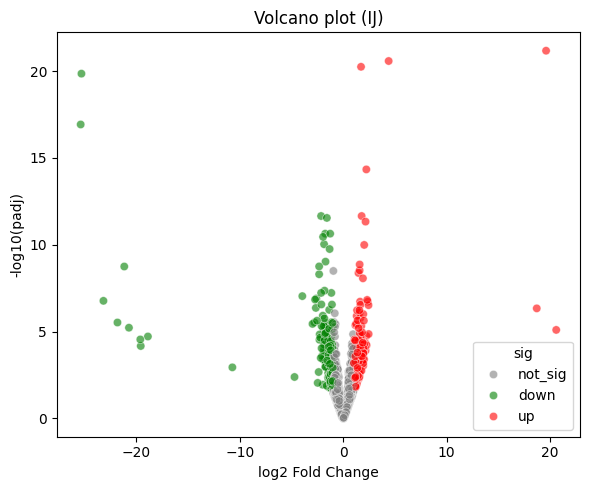

In [30]:
# volcano plot for IJ 

df = res_ij.copy()

# make a new column for the group
df["sig"] = "not_sig"

# make short names
fc = df["log2FoldChange"]
p = df["padj"]

# up genes
df["sig"][(p < 0.05) & (fc > 1)] = "up"

# down genes
df["sig"][(p < 0.05) & (fc < -1)] = "down"

# volcano for IJ
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x="log2FoldChange",
    y=-np.log10(df["padj"]),
    hue="sig",
    palette={"not_sig":"grey", "up":"red", "down":"green"},
    alpha=0.6
)

plt.title("Volcano plot (IJ)")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")

plt.tight_layout()
plt.show()



In [33]:
# Summary statistics for IJ
print("Summary for IJ")

print("Significant up genes:", up_ij)
print("Significant down genes:", down_ij)

print("log2FoldChange summary:")
print(res_ij["log2FoldChange"].describe())

print("padj summary:")
print(res_ij["padj"].describe())


# Summary statistics for IE
print("Summary for I")

print("Significant up genes:", up_ie)
print("Significant down genes:", down_ie)

print("log2FoldChange summary:")
print(res_ie["log2FoldChange"].describe())

print("padj summary:")
print(res_ie["padj"].describe())


Summary for IJ
Significant up genes:       gene_id    baseMean  log2FoldChange     lfcSE    pvalue      padj
48    YAL003W   339.87800        1.397373  0.359983  0.000003  0.000119
55    YAL012W   169.71280        1.329831  0.549077  0.000289  0.003973
57    YAL014C    22.49004        1.367039  0.413250  0.000023  0.000570
66    YAL023C    84.96818        1.115197  0.380259  0.000096  0.001748
83    YAL038W   365.15980        1.200464  0.449713  0.000191  0.002980
...       ...         ...             ...       ...       ...       ...
6246  YPR043W   171.08500        1.201031  0.805605  0.001732  0.015209
6278  YPR080W  2247.10800        1.810809  0.534156  0.000009  0.000272
6297  YPR102C   482.04780        1.369023  0.361497  0.000005  0.000162
6332  YPR139C    22.66028        1.122125  0.454000  0.000372  0.004746
6376  YPR183W    76.59562        1.188827  0.478911  0.000323  0.004256

[237 rows x 6 columns]
Significant down genes:         gene_id    baseMean  log2FoldChange     lfc

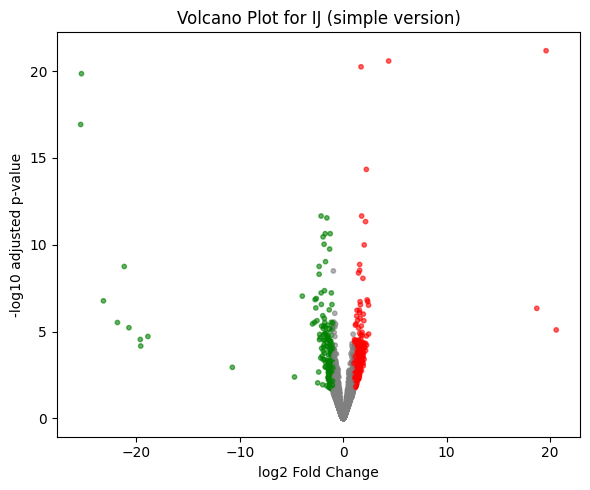

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# make a volcano plot for IJ comparison
df = res_ij.copy()

# make a new column
df["sig"] = "no"
df.loc[(df["padj"] < 0.05) & (df["log2FoldChange"] > 1), "sig"] = "up"
df.loc[(df["padj"] < 0.05) & (df["log2FoldChange"] < -1), "sig"] = "down"

# set colors
colors = {"no": "grey", "up": "red", "down": "green"}

# volcano plot
plt.figure(figsize=(6,5))
plt.scatter(
    df["log2FoldChange"],
    -np.log10(df["padj"]),
    c=df["sig"].map(colors),
    alpha=0.6,
    s=10
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot for IJ (simple version)")

plt.tight_layout()
plt.savefig("volcano_IJ.png",)
plt.show()


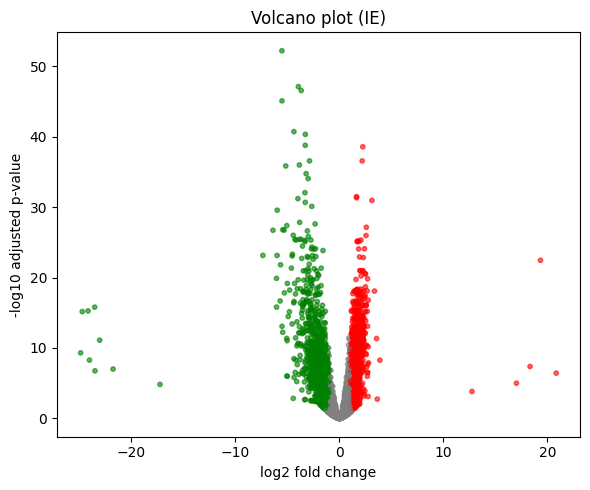

In [50]:
# volcano plot for IE
df_ie = res_ie.copy()

df_ie["sig"] = "no"
fc_ie = df_ie["log2FoldChange"]
p_ie = df_ie["padj"]

df_ie.loc[(p_ie < 0.05) & (fc_ie > 1), "sig"] = "up"
df_ie.loc[(p_ie < 0.05) & (fc_ie < -1), "sig"] = "down"

colors_ie = {"no": "grey", "up": "red", "down": "green"}

plt.figure(figsize=(6, 5))
plt.scatter(
    df_ie["log2FoldChange"],
    -np.log10(df_ie["padj"]),
    c=df_ie["sig"].map(colors_ie),
    s=10,
    alpha=0.6,
)

plt.xlabel("log2 fold change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot (IE)")
plt.tight_layout()

plt.savefig("volcano_IE.png",)
plt.show()


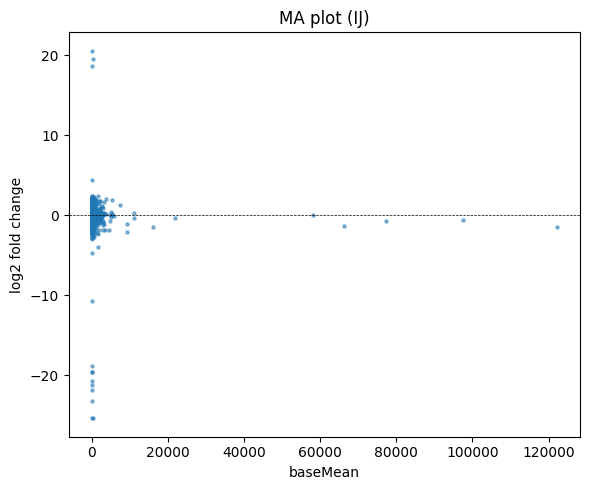

In [38]:
# MA plot for IJ
plt.figure(figsize=(6, 5))

x_ij = res_ij["baseMean"]
y_ij = res_ij["log2FoldChange"]

plt.scatter(x_ij, y_ij, s=5, alpha=0.5)
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)

plt.xlabel("baseMean")
plt.ylabel("log2 fold change")
plt.title("MA plot (IJ)")
plt.tight_layout()

plt.savefig("MA_IJ.png",)
plt.show()


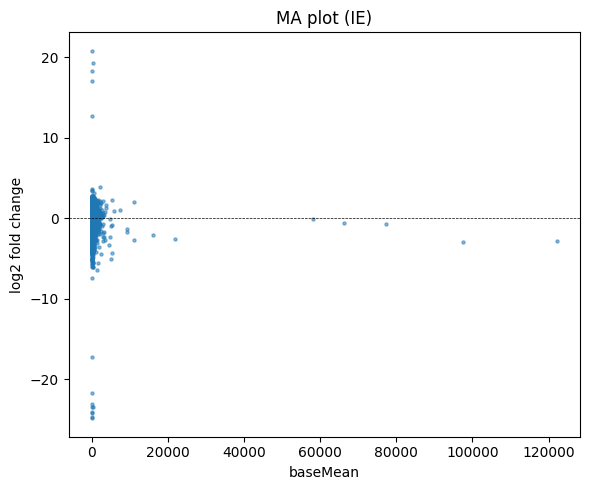

In [39]:
# MA plot for IE
plt.figure(figsize=(6, 5))

x_ie = res_ie["baseMean"]
y_ie = res_ie["log2FoldChange"]

plt.scatter(x_ie, y_ie, s=5, alpha=0.5)
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)

plt.xlabel("baseMean")
plt.ylabel("log2 fold change")
plt.title("MA plot (IE)")
plt.tight_layout()

plt.savefig("MA_IE.png", dpi=300)
plt.show()


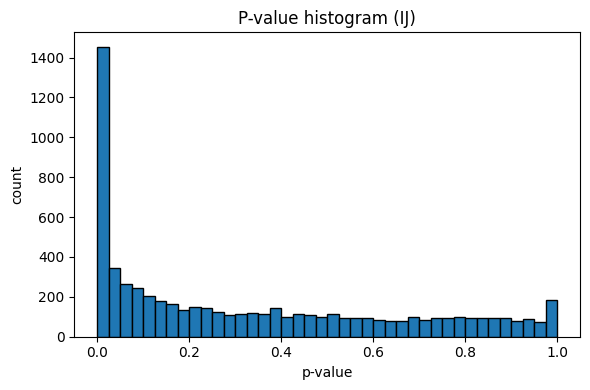

In [41]:
# p-value histogram for IJ
plt.figure(figsize=(6, 4))

plt.hist(res_ij["pvalue"].dropna(), bins=40, edgecolor="black")
plt.xlabel("p-value")
plt.ylabel("count")
plt.title("P-value histogram (IJ)")
plt.tight_layout()

plt.savefig("p_hist_IJ.png",)
plt.show()


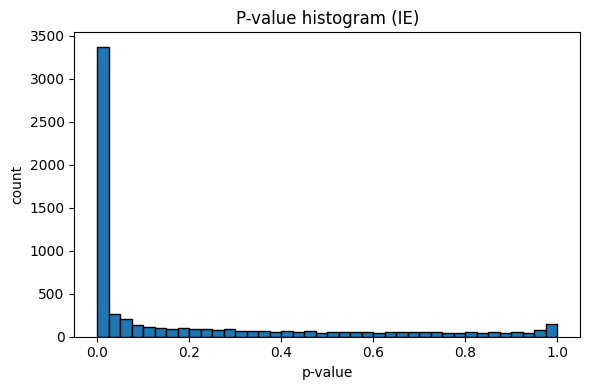

In [42]:
# p-value histogram for IE
plt.figure(figsize=(6, 4))

plt.hist(res_ie["pvalue"].dropna(), bins=40, edgecolor="black")
plt.xlabel("p-value")
plt.ylabel("count")
plt.title("P-value histogram (IE)")
plt.tight_layout()

plt.savefig("p_hist_IE.png",)
plt.show()


number of common top genes: 2


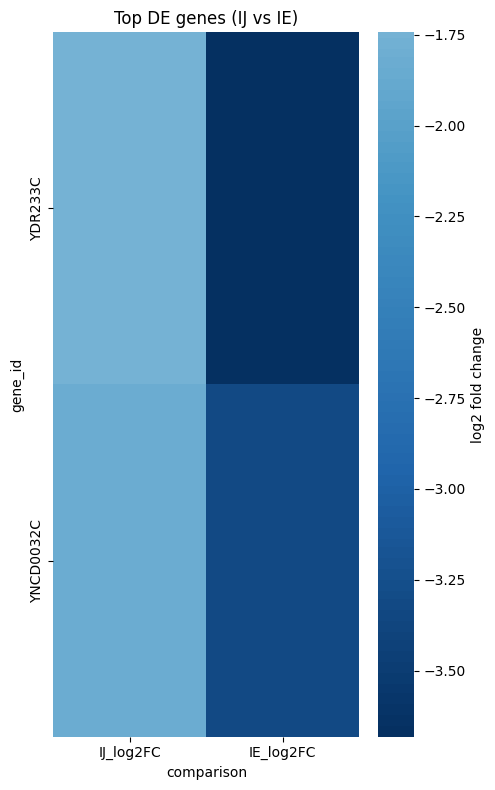

In [43]:
# heatmap for top DE genes (IJ and IE)

top_n = 50

# take top genes 
top_ij = res_ij.sort_values("padj").head(top_n)
top_ie = res_ie.sort_values("padj").head(top_n)

# find common genes
common_genes = set(top_ij["gene_id"]) & set(top_ie["gene_id"])
common_genes = list(common_genes)

print("number of common top genes:", len(common_genes))

if len(common_genes) > 0:
    # make small matrix: rows = genes, columns = IJ/IE log2FC
    ij_fc = res_ij.set_index("gene_id").loc[common_genes, "log2FoldChange"]
    ie_fc = res_ie.set_index("gene_id").loc[common_genes, "log2FoldChange"]

    heat_df = pd.DataFrame({
        "IJ_log2FC": ij_fc,
        "IE_log2FC": ie_fc
    })

    heat_df = heat_df.sort_index()

    plt.figure(figsize=(5, 8))
    sns.heatmap(
        heat_df,
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "log2 fold change"}
    )
    plt.title("Top DE genes (IJ vs IE)")
    plt.ylabel("gene_id")
    plt.xlabel("comparison")
    plt.tight_layout()

    plt.savefig("heatmap_top_genes.png",)
    plt.show()
else:
    print("no common genes in top lists, cannot make heatmap")


In [45]:
# save significant gene lists for IJ and IE

up_ij.to_csv("sig_up_IJ.csv", index=False)
down_ij.to_csv("sig_down_IJ.csv", index=False)
up_ie.to_csv("sig_up_IE.csv", index=False)
down_ie.to_csv("sig_down_IE.csv", index=False)
